In [1]:
# Import necessary libraries 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

### Regularization
<h4>In simple words regularization is the process of penalizing the model to avoid overfitting using different types of penalties.
These penalties are of two types : L1 norm (Lasso) and L2(Ridge).</h4>
Ridge regularization penalizes value by driving weights towards zero but never zero.<br>
Lasso regularization can penalize one step further and create a weight of that node to be zero ,
<br>meaning removing an input directly from that node , causing automatic feature selection.
<br>
<p>Use Ridge regression when all the features are important and use lasso when we can afford removing redundant features </p>

In [13]:
# For this we will be making our custom dataset using make_moons
X, y = make_moons(
                    250, 
                    noise=0.23,
                    random_state=15
                    )

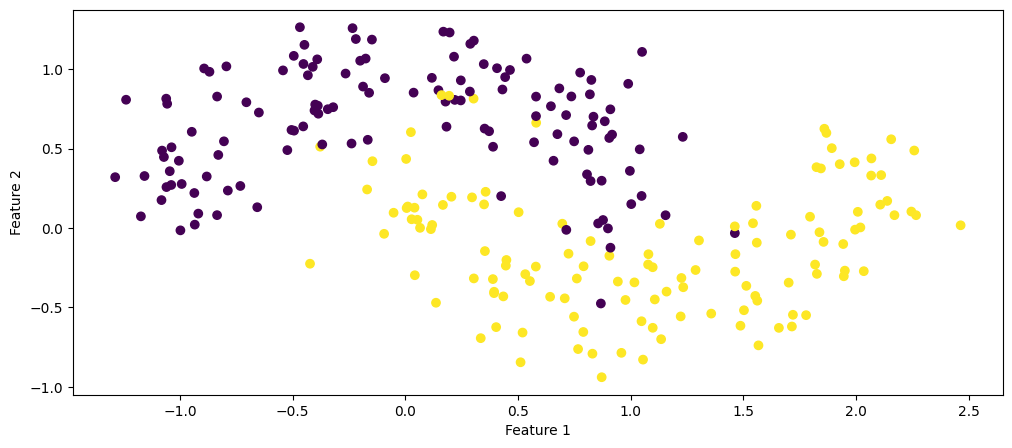

In [14]:
# Let's Visualize this 
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [15]:
# Now let's split the dataset for our model training later
X_train,X_test,y_train,y_test = train_test_split(
                                                    X,y,
                                                    test_size = 0.2,
                                                    random_state = 42
)

In [16]:
# Now let's train the model without regularization and check it's performance

In [18]:
# Instantiating the model with a simple classification setup where the activation function for the hidden layer is relu and the 
# activation function for the final output layer is sigmoid

model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary() # There are a total of  17,025 params

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Model compiling using an explicit learning rate for adam and fitting 

adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history = model.fit(X, y, epochs=250, validation_data=(X_test,y_test),verbose=1)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9360 - loss: 0.3979 - val_accuracy: 0.9000 - val_loss: 0.1548
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9240 - loss: 0.2399 - val_accuracy: 0.9000 - val_loss: 0.1308
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9440 - loss: 0.2068 - val_accuracy: 0.9000 - val_loss: 0.1822
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9440 - loss: 0.1509 - val_accuracy: 0.9400 - val_loss: 0.1429
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9600 - loss: 0.1250 - val_accuracy: 0.9200 - val_loss: 0.1225
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9640 - loss: 0.1149 - val_accuracy: 0.9000 - val_loss: 0.1428
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9520 - loss: 0.1196 - val_accuracy: 0.9000 - val_loss: 0.1497
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9520 - loss: 0.1077 - val_accuracy: 0.9400 - val_loss

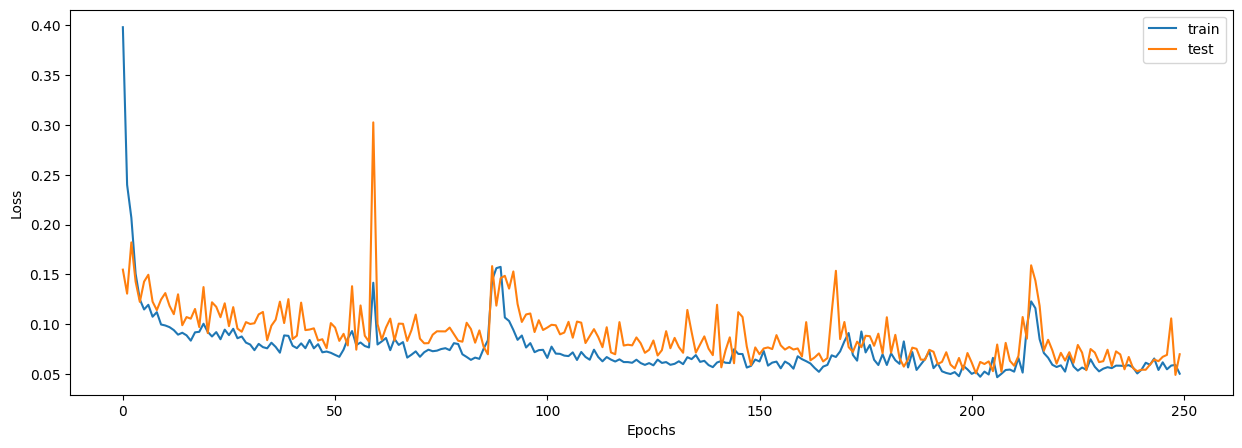

In [ ]:
# Now lets plot this into the graph
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Really good to be honest the model converges well

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step


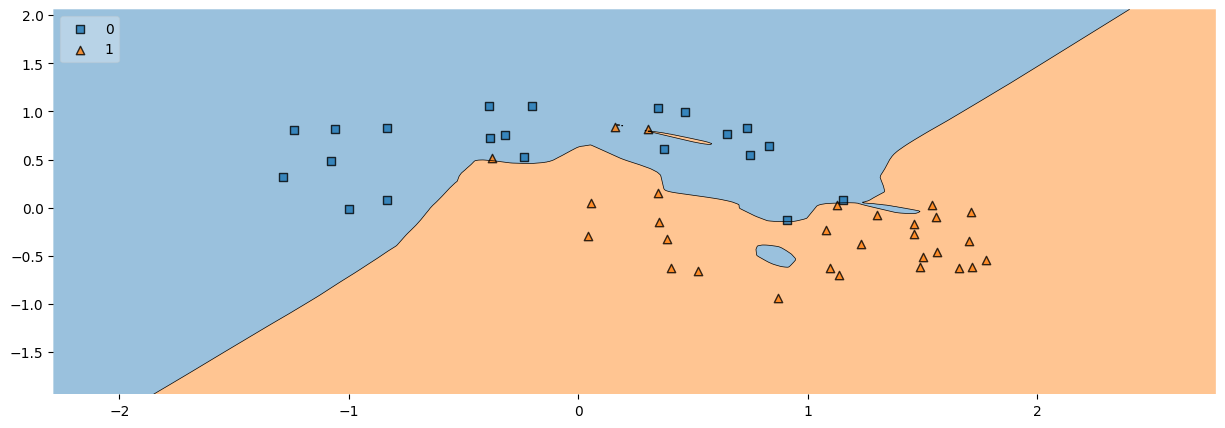

In [24]:
# Also plot the decision boundary to look for how well the model fits the data
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [25]:
# Yeah this reveal this true pattern of the model , now as we can see the lakes forming ; the model is learning values and it;s position
# and not generalizing well , we need a smoother curve which will help to make a generalized well decision when a newer value is predicted